# Clinical Supply Chain (CSC) — Full Pipeline Walkthrough

This notebook walks through the **CSC multi-agent supply chain planning system** end-to-end: from generating synthetic clinical trial data, through the 5-agent LLM pipeline, to analysis plots of every output.

---

## System Architecture

```
┌─────────────────────────────────────────────────────────────────────┐
│                     CLINICAL SUPPLY CHAIN PIPELINE                   │
│                                                                       │
│  JSON Data Files                                                      │
│  (trials, sites,  ──► SharedState Blackboard                         │
│   plants, depots,      (in-memory, read/write by all agents)         │
│   materials, ...)      │                                              │
│                        │                                              │
│                        ▼                                              │
│              ┌─────────────────┐                                      │
│              │  Agent 1        │  Demand Review                       │
│              │  DemandPlan ◄───┤  • S-curve enrollment forecast       │
│              └────────┬────────┘  • Kit demand per site/month         │
│                       │           • Overage & safety stock            │
│                       ▼                                               │
│              ┌─────────────────┐                                      │
│              │  Agent 2        │  Portfolio Review                    │
│              │  PortfolioPlan  │  • Cross-trial prioritization        │
│              └────────┬────────┘  • Conflict detection                │
│                       │           • Resource allocation               │
│                       ▼                                               │
│              ┌─────────────────┐                                      │
│              │  Agent 3        │  Supply Review                       │
│              │  SupplyPlan ◄───┤  • DS → DP → PP → FG planning       │
│              └────────┬────────┘  • Batch scheduling & transport      │
│                       │                                               │
│               ┌───────┴───────┐                                       │
│               ▼               ▼                                       │
│     ┌──────────────┐  ┌──────────────┐                                │
│     │  Agent 4     │  │  Agent 5     │  Capacity Validation           │
│     │  Depot Cap.  │  │  Plant Cap.  │  • Packaging/labeling lines    │
│     └──────────────┘  └──────────────┘  • Manufacturing reactors      │
│               │               │                                       │
│               └───────┬───────┘                                       │
│                       ▼                                               │
│              Conflict Resolver  ──► Reports (CSV + JSON)              │
└─────────────────────────────────────────────────────────────────────┘
```

**Key concepts:**
- Each agent runs a tool-use agentic loop (up to `max_turns` iterations) powered by Claude
- Agents communicate exclusively through the **SharedState blackboard** — no direct agent-to-agent calls
- The supply chain stages are: DS (Drug Substance) → DP (Drug Product) → PP (Primary Pack) → FG (Finished Good)


## 0. Setup

Install visualization dependencies and configure the Python path for the `src/` layout.

In [1]:
# Install extra visualization libraries (skip if already installed)
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "matplotlib", "pandas", "seaborn", "-q"], check=True)

import sys
from pathlib import Path

# Add the project src/ directory to sys.path
repo_root = Path("../").resolve()
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f"Project root : {repo_root}")
print(f"Source path  : {src_path}")

# Load environment variables from .env (ANTHROPIC_API_KEY etc.)
from dotenv import load_dotenv
loaded = load_dotenv(repo_root / ".env")
print(f"Loaded .env  : {loaded}")

Project root : C:\Users\Ferhat\Documents\GitHub\csc-skill-test
Source path  : C:\Users\Ferhat\Documents\GitHub\csc-skill-test\src
Loaded .env  : True


In [2]:
import os
import random
from datetime import date, datetime, timedelta
from collections import defaultdict
from uuid import uuid4

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns

# CSC models
from csc.models.common import (
    BatchStatus, Region, SupplyChainStage, TherapyArea, TrialPhase, UnitOfMeasure, Urgency
)
from csc.models.demand import DemandPlan, SiteDemand
from csc.models.supply import Batch, SupplyPlan
from csc.models.capacity import CapacityCalendar, DepotCapacityPlan, PlantCapacityPlan
from csc.orchestrator.state import PortfolioPlan

# Plotting style
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3",
           "#937860", "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD"]
print("Imports OK")

Imports OK


---
## 1. Synthetic Data Generation

The `MasterGenerator` creates a fully coherent, self-referencing dataset that simulates a real pharmaceutical company's clinical supply data. Everything is generated deterministically from a `seed` so results are reproducible.

**Generation order (dependency graph):**
```
Plants → Depots → Sites → Transport Lanes → Equipment Lines
                                  ↓
                    Trials & Materials (DS → DP → PP → FG)
                                  ↓
                    Enrollment Forecasts → Patient Cohorts → Inventory
```

The generator supports configuring:
- `seed` — reproducibility (default `42`)
- `num_sites` — number of clinical sites (default `30`)
- `base_date` — the reference date for "today" (default `2026-01-01`)


In [3]:
from csc.data.master_generator import MasterGenerator

# Generate synthetic data (deterministic, ~1-2 seconds)
gen = MasterGenerator(seed=42, num_sites=30, base_date=date(2026, 1, 1))
gen.generate()

# Save to disk so the CLI and pipeline can read it
output_dir = repo_root / "src" / "csc" / "data" / "output"
gen.save(output_dir)

print("Generated dataset:")
print(f"  {len(gen.trials):>4} trials")
print(f"  {len(gen.sites):>4} clinical sites")
print(f"  {len(gen.plants):>4} pilot plants")
print(f"  {len(gen.depots):>4} packing depots")
print(f"  {len(gen.materials.drug_substances):>4} drug substances (DS)")
print(f"  {len(gen.materials.drug_products):>4} drug products (DP)")
print(f"  {len(gen.materials.primary_packs):>4} primary packs (PP)")
print(f"  {len(gen.materials.finished_goods):>4} finished goods (FG)")
print(f"  {len(gen.enrollment_forecasts):>4} enrollment forecast records")
print(f"  {len(gen.equipment_lines):>4} equipment lines")
print(f"  {len(gen.transport_lanes):>4} transport lanes")
print(f"  Saved to: {output_dir}")

Generated dataset:
    15 trials
    30 clinical sites
     2 pilot plants
     6 packing depots
    15 drug substances (DS)
    15 drug products (DP)
    15 primary packs (PP)
    15 finished goods (FG)
  2627 enrollment forecast records
    31 equipment lines
    39 transport lanes
  Saved to: C:\Users\Ferhat\Documents\GitHub\csc-skill-test\src\csc\data\output


### 1.1 Exploratory Plots: Dataset Overview

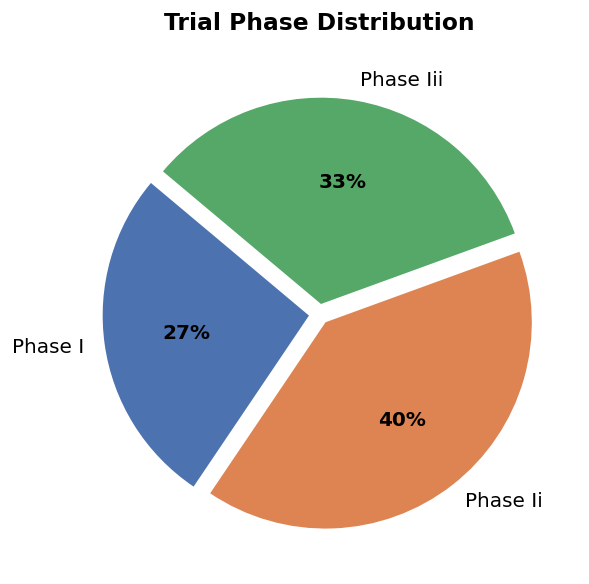

In [4]:
# Plot 1 — Trial Phase Distribution
phase_counts = defaultdict(int)
for t in gen.trials:
    phase_counts[t.phase.value] += 1

labels = [p.replace("_", " ").title() for p in phase_counts.keys()]
sizes  = list(phase_counts.values())
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
explode = [0.05] * len(labels)

fig, ax = plt.subplots(figsize=(6, 5))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct="%1.0f%%",
    colors=colors[:len(labels)], explode=explode,
    startangle=140, textprops={"fontsize": 12}
)
for at in autotexts:
    at.set_fontweight("bold")
ax.set_title("Trial Phase Distribution", fontsize=14, fontweight="bold", pad=16)
plt.tight_layout()
plt.show()

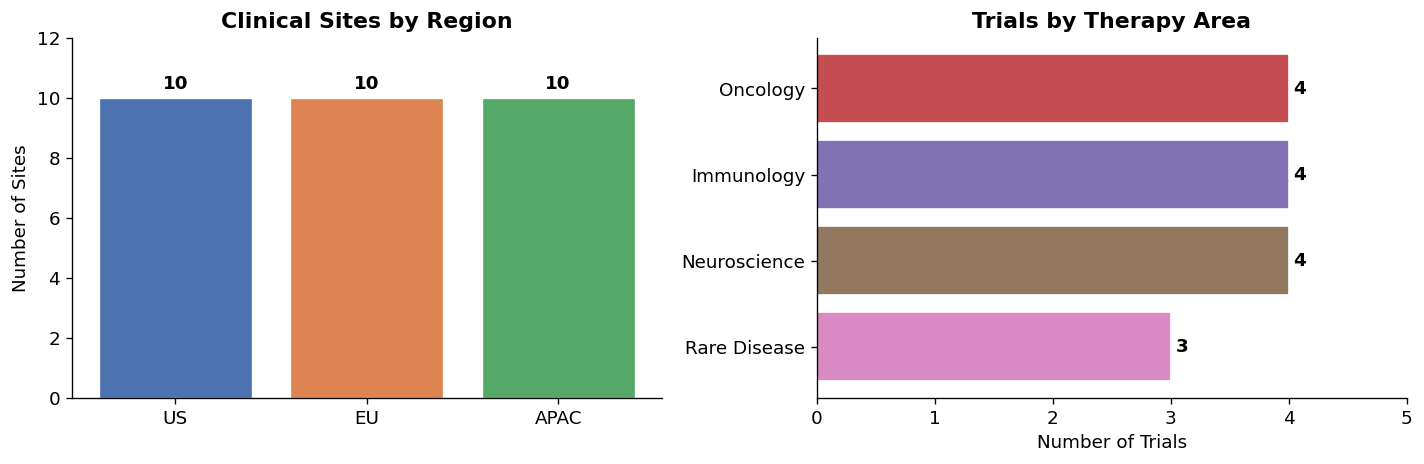

In [5]:
# Plot 2 — Clinical Sites by Region and Therapy Area mix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: sites per region
region_counts = defaultdict(int)
for s in gen.sites:
    region_counts[s.region.value.upper()] += 1

ax = axes[0]
bars = ax.bar(region_counts.keys(), region_counts.values(),
              color=PALETTE[:3], edgecolor="white", linewidth=0.8)
ax.bar_label(bars, padding=3, fontweight="bold")
ax.set_title("Clinical Sites by Region", fontweight="bold")
ax.set_ylabel("Number of Sites")
ax.set_ylim(0, max(region_counts.values()) * 1.2)

# Right: trials per therapy area
area_counts = defaultdict(int)
for t in gen.trials:
    area_counts[t.therapy_area.value.replace("_", " ").title()] += 1

ax2 = axes[1]
sorted_areas = sorted(area_counts.items(), key=lambda x: -x[1])
area_labels = [a[0] for a in sorted_areas]
area_vals   = [a[1] for a in sorted_areas]
bars2 = ax2.barh(area_labels, area_vals,
                 color=PALETTE[3:3+len(area_labels)], edgecolor="white")
ax2.bar_label(bars2, padding=3, fontweight="bold")
ax2.set_title("Trials by Therapy Area", fontweight="bold")
ax2.set_xlabel("Number of Trials")
ax2.set_xlim(0, max(area_vals) * 1.25)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

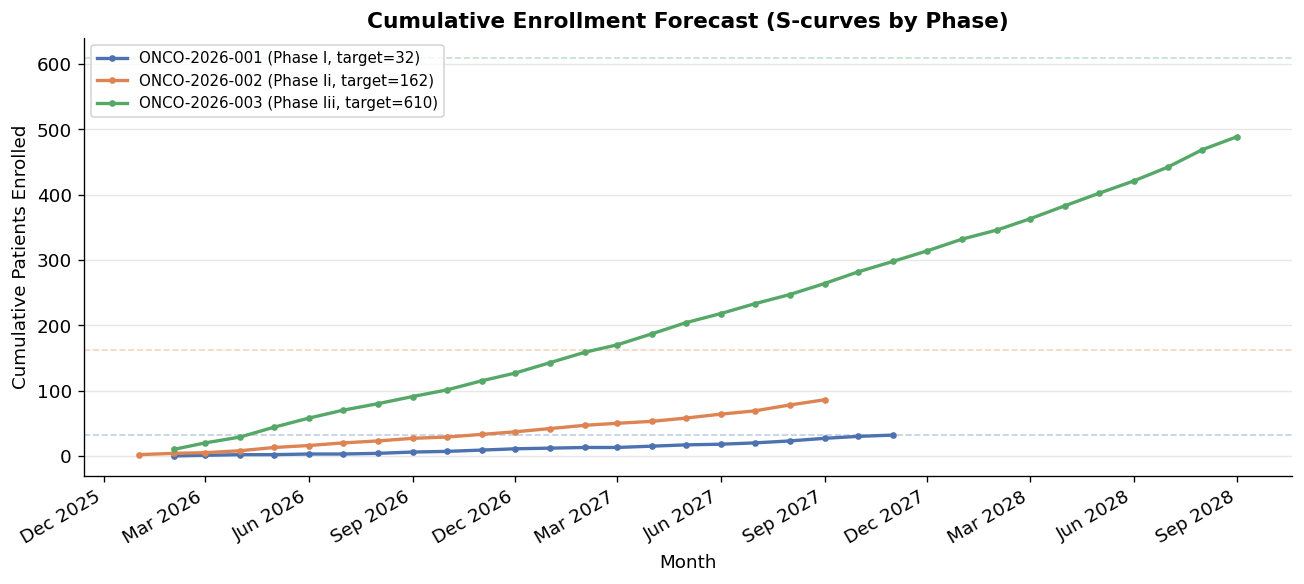

In [6]:
# Plot 3 — Enrollment S-curves for 3 sample trials
# Pick one trial per phase for comparison
sample_trials = {}
for trial in gen.trials:
    if trial.phase not in sample_trials:
        sample_trials[trial.phase] = trial
    if len(sample_trials) == 3:
        break

fig, ax = plt.subplots(figsize=(11, 5))

phase_colors = {
    TrialPhase.PHASE_I:   "#4C72B0",
    TrialPhase.PHASE_II:  "#DD8452",
    TrialPhase.PHASE_III: "#55A868",
}

for phase, trial in sample_trials.items():
    # Aggregate enrollment across all sites for this trial
    by_month = defaultdict(int)
    for f in gen.enrollment_forecasts:
        if f.trial_id == trial.id:
            by_month[f.month] += f.forecasted_new_patients

    months = sorted(by_month.keys())
    cumulative = []
    running = 0
    for m in months:
        running += by_month[m]
        cumulative.append(running)

    label = f"{trial.protocol_number} ({phase.value.replace('_',' ').title()}, target={trial.planned_enrollment})"
    ax.plot([pd.Timestamp(m) for m in months], cumulative,
            marker="o", markersize=3, linewidth=2,
            color=phase_colors[phase], label=label)
    ax.axhline(trial.planned_enrollment, color=phase_colors[phase],
               linestyle="--", alpha=0.35, linewidth=1)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha="right")
ax.set_title("Cumulative Enrollment Forecast (S-curves by Phase)", fontsize=13, fontweight="bold")
ax.set_ylabel("Cumulative Patients Enrolled")
ax.set_xlabel("Month")
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

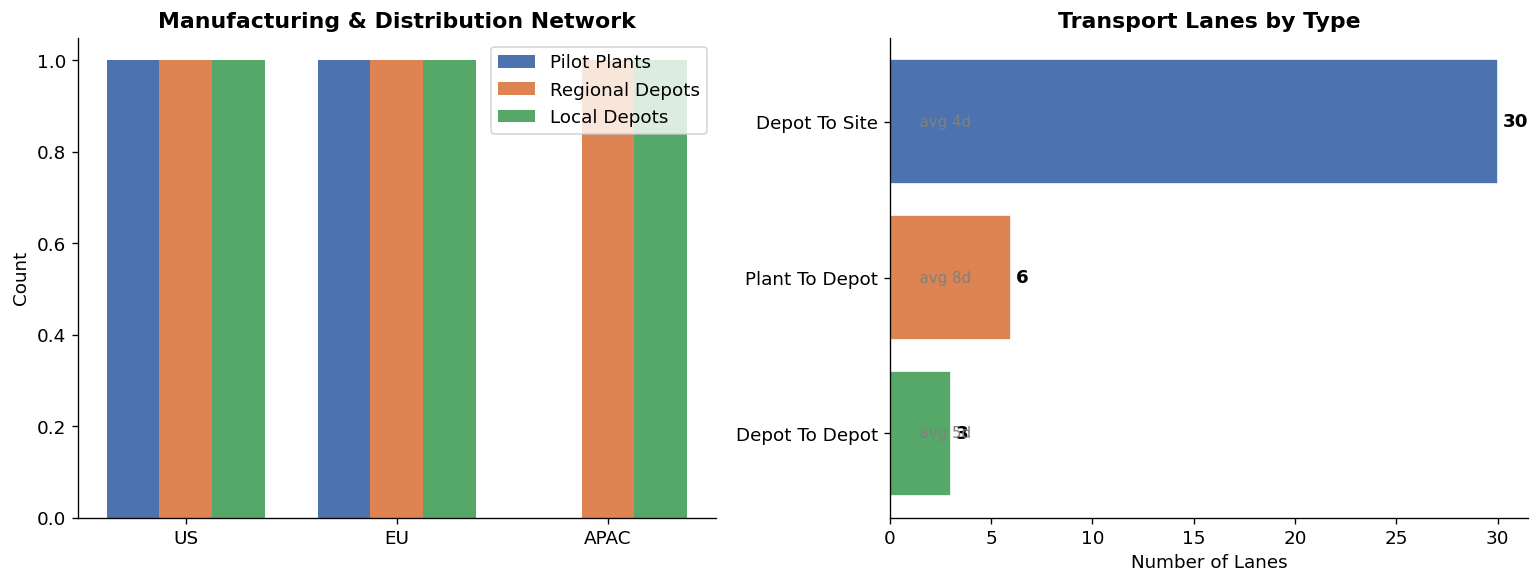

In [7]:
# Plot 4 — Supply Chain Network: entity counts and types
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: plants vs depots (regional/local) by region
ax = axes[0]
regions = [r.value.upper() for r in Region]
plant_counts   = [sum(1 for p in gen.plants if p.region.value.upper() == r) for r in regions]
rdepot_counts  = [sum(1 for d in gen.depots if d.region.value.upper() == r and d.depot_type == "regional") for r in regions]
ldepot_counts  = [sum(1 for d in gen.depots if d.region.value.upper() == r and d.depot_type == "local") for r in regions]

x = range(len(regions))
width = 0.25
ax.bar([xi - width for xi in x], plant_counts,  width, label="Pilot Plants",   color="#4C72B0")
ax.bar([xi         for xi in x], rdepot_counts, width, label="Regional Depots", color="#DD8452")
ax.bar([xi + width for xi in x], ldepot_counts, width, label="Local Depots",    color="#55A868")
ax.set_xticks(list(x))
ax.set_xticklabels(regions)
ax.set_title("Manufacturing & Distribution Network", fontweight="bold")
ax.set_ylabel("Count")
ax.legend()

# Right: transport lane types
ax2 = axes[1]
lane_types = defaultdict(int)
for lane in gen.transport_lanes:
    lane_types[lane.lane_type.replace("_", " ").title()] += 1

sorted_lanes = sorted(lane_types.items(), key=lambda x: -x[1])
ll, lv = zip(*sorted_lanes)
lead_times = {lt: [] for lt in ll}
for lane in gen.transport_lanes:
    key = lane.lane_type.replace("_", " ").title()
    lead_times[key].append(lane.lead_time_days)

avg_leads = [sum(lead_times[k]) / len(lead_times[k]) for k in ll]

bars = ax2.barh(list(ll), list(lv), color=PALETTE[:len(ll)], edgecolor="white")
ax2.bar_label(bars, padding=3, fontweight="bold")
ax2.set_title("Transport Lanes by Type", fontweight="bold")
ax2.set_xlabel("Number of Lanes")
ax2.invert_yaxis()

# Annotate with avg lead times
for i, (k, avg) in enumerate(zip(ll, avg_leads)):
    ax2.text(1, i, f"  avg {avg:.0f}d", va="center", fontsize=9, color="gray")

plt.tight_layout()
plt.show()

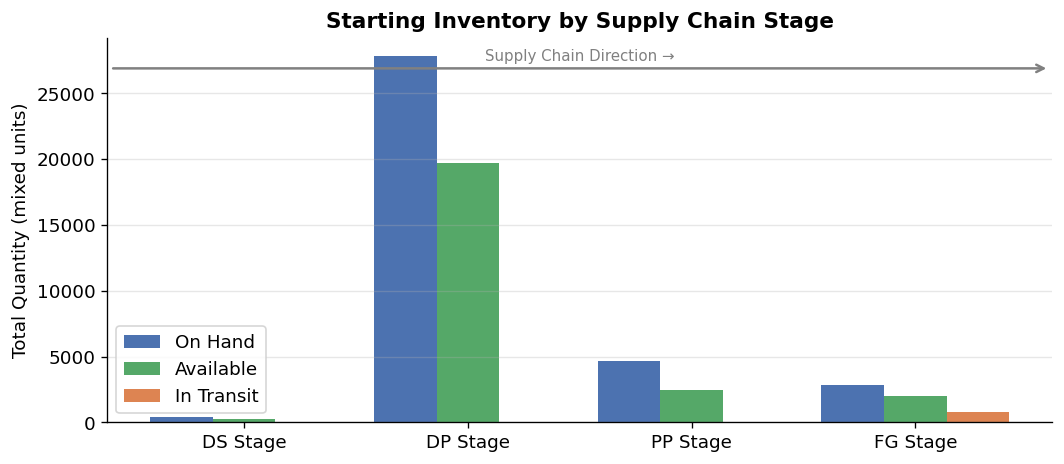

In [8]:
# Plot 5 — Starting Inventory Levels by Material Stage
stage_map = {
    "DS": [m.id for m in gen.materials.drug_substances],
    "DP": [m.id for m in gen.materials.drug_products],
    "PP": [m.id for m in gen.materials.primary_packs],
    "FG": [m.id for m in gen.materials.finished_goods],
}

stage_on_hand    = {}
stage_available  = {}
stage_in_transit = {}

for stage_label, mat_ids in stage_map.items():
    mat_id_set = set(mat_ids)
    positions = [p for p in gen.inventory_positions if p.material_id in mat_id_set]
    stage_on_hand[stage_label]    = sum(p.on_hand for p in positions)
    stage_available[stage_label]  = sum(p.available for p in positions)
    stage_in_transit[stage_label] = sum(p.in_transit for p in positions)

fig, ax = plt.subplots(figsize=(9, 4))
stages = list(stage_map.keys())
x = range(len(stages))
width = 0.28

b1 = ax.bar([xi - width for xi in x], [stage_on_hand[s]    for s in stages], width, label="On Hand",    color="#4C72B0")
b2 = ax.bar([xi         for xi in x], [stage_available[s]  for s in stages], width, label="Available",  color="#55A868")
b3 = ax.bar([xi + width for xi in x], [stage_in_transit[s] for s in stages], width, label="In Transit", color="#DD8452")

ax.set_xticks(list(x))
ax.set_xticklabels([f"{s} Stage" for s in stages])
ax.set_title("Starting Inventory by Supply Chain Stage", fontsize=13, fontweight="bold")
ax.set_ylabel("Total Quantity (mixed units)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Add arrow showing direction of flow
ax.annotate("", xy=(3.6, ax.get_ylim()[1] * 0.92), xytext=(-0.6, ax.get_ylim()[1] * 0.92),
            arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax.text(1.5, ax.get_ylim()[1] * 0.94, "Supply Chain Direction →", ha="center", color="gray", fontsize=9)

plt.tight_layout()
plt.show()

---
## 2. The SharedState Blackboard

All agents communicate through a central `SharedState` object — a Pydantic-based in-memory store.
- **Reference data** (trials, sites, materials, …) is loaded from JSON files at startup
- **Agent outputs** (`demand_plan`, `supply_plan`, …) are `None` until the corresponding agent runs
- Any agent can read any field; each agent writes only its own output key

```python
state = SharedState()
state.load_from_dir(data_dir)   # populate reference data

# After demand agent runs:
state.demand_plan          # → DemandPlan

# After supply agent runs:
state.supply_plan          # → SupplyPlan
```

In [9]:
from csc.orchestrator.state import SharedState

state = SharedState()
state.load_from_dir(output_dir)

print(f"Loaded into SharedState:")
print(f"  trials            : {len(state.trials)}")
print(f"  sites             : {len(state.sites)}")
print(f"  plants            : {len(state.plants)}")
print(f"  depots            : {len(state.depots)}")
print(f"  equipment_lines   : {len(state.equipment_lines)}")
print(f"  enrollment_fcsts  : {len(state.enrollment_forecasts)}")
print(f"  inventory_pos     : {len(state.inventory_positions)}")
print()
print("Agent outputs (None = not yet run):")
print(f"  demand_plan       : {state.demand_plan}")
print(f"  portfolio_plan    : {state.portfolio_plan}")
print(f"  supply_plan       : {state.supply_plan}")
print(f"  depot_capacity    : {state.depot_capacity_plan}")
print(f"  plant_capacity    : {state.plant_capacity_plan}")

Loaded into SharedState:
  trials            : 15
  sites             : 30
  plants            : 2
  depots            : 6
  equipment_lines   : 31
  enrollment_fcsts  : 2627
  inventory_pos     : 60

Agent outputs (None = not yet run):
  demand_plan       : None
  portfolio_plan    : None
  supply_plan       : None
  depot_capacity    : None
  plant_capacity    : None


In [10]:
# Inspect trials as a DataFrame
trials_df = pd.DataFrame([
    {
        "protocol": t.protocol_number,
        "therapy_area": t.therapy_area.value,
        "phase": t.phase.value,
        "planned_enrollment": t.planned_enrollment,
        "num_sites": len(t.sites),
        "num_arms": len(t.arms),
        "overage_pct": t.overage_pct,
        "fsfv": str(t.fsfv),
        "lslv": str(t.lslv),
    }
    for t in state.trials
])

print(f"Trial portfolio ({len(trials_df)} trials):")
trials_df.head(10)

Trial portfolio (15 trials):


,protocol,therapy_area,phase,planned_enrollment,num_sites,num_arms,overage_pct,fsfv,lslv
0,ONCO-2026-001,oncology,phase_i,32,2,1,0.25,2026-02-06,2027-11-28
1,ONCO-2026-002,oncology,phase_ii,162,7,2,0.20,2026-01-29,2027-09-21
2,ONCO-2026-003,oncology,phase_iii,610,14,2,0.15,2026-02-24,2028-09-11
3,ONCO-2026-004,oncology,phase_ii,189,4,2,0.20,2026-01-26,2028-11-11
4,IMMU-2026-005,immunology,phase_i,31,2,1,0.25,2026-01-15,2027-09-07
5,IMMU-2026-006,immunology,phase_ii,69,7,2,0.20,2026-04-28,2027-03-24
6,IMMU-2026-007,immunology,phase_iii,567,12,2,0.15,2026-02-22,2028-06-11
7,IMMU-2026-008,immunology,phase_iii,252,15,2,0.15,2026-05-24,2027-12-15
8,NEUR-2026-009,neuroscience,phase_i,42,1,1,0.25,2026-02-28,2029-10-10
9,NEUR-2026-010,neuroscience,phase_ii,180,7,2,0.20,2026-06-05,2027-12-27


---
## 3. Running the Full Pipeline

The `SupplyChainPipeline` orchestrates all 5 agents in sequence. Each agent:
1. Reads its required fields from `SharedState`
2. Enters a **tool-use agentic loop** with Claude (up to `max_turns` rounds)
3. Writes its structured output back to `SharedState`

| Agent | Class | Input Keys | Output Key |
|-------|-------|-----------|------------|
| Demand Review | `DemandReviewAgent` | `trials`, `sites`, `enrollment_forecasts`, `materials` | `demand_plan` |
| Portfolio Review | `PortfolioReviewAgent` | `trials`, `demand_plan`, `materials`, `plants`, `depots` | `portfolio_plan` |
| Supply Review | `SupplyReviewAgent` | `demand_plan`, `portfolio_plan`, `materials`, `inventory_positions`, `plants`, `depots` | `supply_plan` |
| Depot Capacity | `DepotCapacityAgent` | `supply_plan`, `depots`, `equipment_lines`, `changeover_rules` | `depot_capacity_plan` |
| Plant Capacity | `PlantCapacityAgent` | `supply_plan`, `plants`, `equipment_lines`, `changeover_rules` | `plant_capacity_plan` |

### Tool-Use Agentic Loop

```
┌──── Agent Loop (max 20 turns) ────────────────────────────────────┐
│                                                                    │
│  1. Send system prompt + context message to Claude                 │
│  2. Claude responds with tool_use blocks (e.g. get_trial_summary)  │
│     → Execute Python tool function                                 │
│     → Return tool result to Claude                                 │
│  3. Repeat until Claude returns plain text (no tool calls)         │
│  4. Extract JSON from response → parse into Pydantic model         │
│  5. Write to SharedState[output_key]                               │
└────────────────────────────────────────────────────────────────────┘
```

> **Requirements:** A valid `ANTHROPIC_API_KEY` in your `.env` file.  
> Set `RUN_PIPELINE = True` below to execute (costs API credits, takes ~2-5 min).

In [11]:
# ─────────────────────────────────────────────────────────────────
# Set RUN_PIPELINE = True to execute the agents (requires API key)
# ─────────────────────────────────────────────────────────────────
RUN_PIPELINE = True

if RUN_PIPELINE:
    from csc.config import Config
    from csc.orchestrator.pipeline import SupplyChainPipeline
    from csc.reports.writer import write_reports

    # Load config from .env (reads ANTHROPIC_API_KEY)
    config = Config.from_env(repo_root / ".env")
    print(f"Model : {config.model}")
    print(f"Turns : {config.max_agent_turns}")

    # Create and run the pipeline
    pipeline = SupplyChainPipeline(config)
    pipeline.load_data(output_dir)
    state = pipeline.run_full()   # executes all 5 agents sequentially

    # Save reports
    reports_dir = repo_root / "reports"
    created = write_reports(state, reports_dir, fmt="both")
    print(f"\nCreated {len(created)} report files in {reports_dir}")
else:
    print("Pipeline not run. Set RUN_PIPELINE = True to execute.")
    print("Continuing with demo data for all visualizations...")

Model : claude-sonnet-4-20250514
Turns : 10


Loading data from C:\Users\Ferhat\Documents\GitHub\csc-skill-test\src\csc\data\output

Loaded: 15 trials, 30 sites, 6 depots, 2 plants

Starting full pipeline

============================================================

...

Rate limit hit — waiting 60s before retry 2/5...

Agent completed after 10 turns

Parse error: 'trial_id'

Max turns (10) exhausted

RuntimeError: demand_review exceeded maximum turns (10)

In [ ]:
# You can also run individual agents for testing:
if RUN_PIPELINE:
    from csc.config import Config
    from csc.orchestrator.pipeline import SupplyChainPipeline

    config = Config.from_env(repo_root / ".env")
    pipeline = SupplyChainPipeline(config)
    pipeline.load_data(output_dir)

    # Run only the demand review agent
    pipeline.run_agent("demand_review")
    print("Demand plan generated:", pipeline.state.demand_plan is not None)
else:
    print("Skipped (RUN_PIPELINE = False)")

---
## 4. Loading Results / Demo Data

The following cell tries to load real pipeline outputs from the `reports/` directory.
If the pipeline hasn't been run yet, it builds **synthetic demo outputs** directly from the generator data so all subsequent plots still work.

This is useful for exploring what the outputs look like before spending API credits.

In [ ]:
# ── Helper utilities ────────────────────────────────────────────────────────

def add_months(d: date, months: int) -> date:
    """Add N months to a date, returning the first day of the result month."""
    m = d.month - 1 + months
    return d.replace(year=d.year + m // 12, month=m % 12 + 1, day=1)


def build_demo_demand_plan(gen: MasterGenerator) -> DemandPlan:
    """Build a plausible DemandPlan from the enrollment forecast data."""
    rng_d = random.Random(42)
    site_demands = []
    demand_by_trial: dict[str, int] = defaultdict(int)
    base = date(2026, 1, 1)

    # trials[i] was generated paired with finished_goods[i]
    for trial, fg in zip(gen.trials, gen.materials.finished_goods):
        overage = 1.0 + trial.overage_pct / 100
        sample_sites = list(trial.sites)[:4]  # limit for clarity

        for month_offset in range(6):
            month = add_months(base, month_offset)
            for site_id in sample_sites:
                base_kits = rng_d.randint(8, 45)
                overage_kits = int(base_kits * overage)
                safety_kits  = max(5, int(base_kits * 0.15))
                site_demands.append(SiteDemand(
                    trial_id=trial.id,
                    site_id=site_id,
                    month=month,
                    finished_good_id=fg.id,
                    quantity_kits=base_kits,
                    quantity_with_overage=overage_kits,
                    safety_stock_kits=safety_kits,
                    urgency=Urgency.ROUTINE,
                ))
                demand_by_trial[trial.protocol_number] += overage_kits

    all_months = sorted({sd.month for sd in site_demands})
    return DemandPlan(
        generated_at=datetime.now(),
        horizon_start=all_months[0],
        horizon_end=all_months[-1],
        site_demands=site_demands,
        total_kit_demand=sum(demand_by_trial.values()),
        demand_by_trial=dict(demand_by_trial),
        assumptions=["Demo mode: base demand = random 8-45 kits/site/month; overage by phase"],
    )


def build_demo_portfolio_plan(gen: MasterGenerator) -> PortfolioPlan:
    """Build a priority ranking based on phase + therapy area heuristics."""
    phase_score  = {"phase_iii": 90, "phase_ii": 65, "phase_i": 40}
    area_score   = {"oncology": 22, "rare_disease": 25, "immunology": 15, "neuroscience": 12}

    ranked = []
    for trial in gen.trials:
        rng_p = random.Random(trial.protocol_number)
        score = (phase_score.get(trial.phase.value, 50)
                 + area_score.get(trial.therapy_area.value, 10)
                 + rng_p.randint(-8, 8))
        ranked.append({
            "trial_id": str(trial.id),
            "protocol": trial.protocol_number,
            "priority_score": score,
            "therapy_area": trial.therapy_area.value,
            "phase": trial.phase.value,
            "planned_enrollment": trial.planned_enrollment,
        })

    ranked.sort(key=lambda x: -x["priority_score"])
    for i, r in enumerate(ranked):
        r["rank"] = i + 1

    return PortfolioPlan(
        generated_at=datetime.now(),
        ranked_trials=ranked,
        conflicts=[],
        synergies=[{"description": "Shared oncology manufacturing slots across Phase II/III"}],
        resource_allocations=[],
        reasoning=["Demo mode: phase criticality + therapeutic area weighting"],
    )


def build_demo_supply_plan(gen: MasterGenerator) -> SupplyPlan:
    """Construct a batch schedule spanning DS → DP → PP → FG for top 8 trials."""
    rng_s = random.Random(99)
    batches = []
    base = date(2026, 1, 1)

    stage_specs = [
        (SupplyChainStage.DRUG_SUBSTANCE, gen.plants,      UnitOfMeasure.KG,    60, 14),
        (SupplyChainStage.DRUG_PRODUCT,   gen.plants,      UnitOfMeasure.UNITS, 40, 10),
        (SupplyChainStage.PRIMARY_PACK,   gen.depots[:3],  UnitOfMeasure.UNITS, 20,  7),
        (SupplyChainStage.FINISHED_GOOD,  gen.depots[:3],  UnitOfMeasure.KITS,   5,  5),
    ]

    mat_lists = [
        gen.materials.drug_substances,
        gen.materials.drug_products,
        gen.materials.primary_packs,
        gen.materials.finished_goods,
    ]

    qty_ranges = [(50, 200), (500, 5000), (200, 2000), (100, 1000)]

    for i, trial in enumerate(gen.trials[:8]):
        lead_offset = 0
        for j, (stage, locations, unit, lead_days, duration) in enumerate(stage_specs):
            loc = locations[i % len(locations)]
            start = base + timedelta(days=lead_days + i * 2 + lead_offset)
            end   = start + timedelta(days=duration)
            mat   = mat_lists[j][i]
            qty   = round(rng_s.uniform(*qty_ranges[j]), 1)

            batches.append(Batch(
                material_id=mat.id,
                stage=stage,
                batch_number=f"B-{trial.protocol_number[-3:]}-{stage.value.upper()}-01",
                quantity=qty,
                unit=unit,
                status=BatchStatus.PLANNED,
                planned_start=start,
                planned_end=end,
                expiry_date=end + timedelta(days=365),
                location_id=loc.id,
            ))
            lead_offset += duration + 2  # chain stages

    return SupplyPlan(
        generated_at=datetime.now(),
        horizon_start=base,
        horizon_end=base + timedelta(days=180),
        batches=batches,
        orders=[],
        shortfall_alerts=[],
        reasoning=["Demo mode: stages chained backward from demand horizon"],
    )


def build_demo_capacity_plans(gen: MasterGenerator):
    """Build DepotCapacityPlan and PlantCapacityPlan with synthetic utilization."""
    rng_c = random.Random(7)

    depot_cals = [
        CapacityCalendar(
            location_id=d.id,
            location_name=d.name,
            month=date(2026, 3, 1),
            utilization_pct=round(rng_c.uniform(42, 93), 1),
            available_slots=rng_c.randint(10, 50),
            bottleneck_lines=[],
        )
        for d in gen.depots
    ]
    # Make one depot over capacity for realism
    depot_cals[1].utilization_pct = 108.3
    depot_cals[1].bottleneck_lines = ["Packaging Line 2"]

    plant_cals = [
        CapacityCalendar(
            location_id=p.id,
            location_name=p.name,
            month=date(2026, 3, 1),
            utilization_pct=round(rng_c.uniform(55, 98), 1),
            available_slots=rng_c.randint(5, 30),
            bottleneck_lines=[],
        )
        for p in gen.plants
    ]

    depot_plan = DepotCapacityPlan(
        generated_at=datetime.now().isoformat(),
        depot_calendars=depot_cals,
        feasible=all(c.utilization_pct <= 100 for c in depot_cals),
        adjustments=["Reschedule labeling campaign for depot 2 to Q2"],
        reasoning=["Demo mode: utilization sampled; depot 2 intentionally over capacity"],
    )

    plant_plan = PlantCapacityPlan(
        generated_at=datetime.now().isoformat(),
        plant_calendars=plant_cals,
        feasible=all(c.utilization_pct <= 100 for c in plant_cals),
        adjustments=[],
        reasoning=["Demo mode: all plants within capacity"],
    )

    return depot_plan, plant_plan


print("Demo builders defined.")

In [ ]:
# Try loading real reports; fall back to demo data
reports_dir = repo_root / "reports"

def try_load(filename, model_class):
    path = reports_dir / filename
    if path.exists():
        print(f"  Loaded real output : {filename}")
        return model_class.model_validate_json(path.read_text())
    return None

demand_plan      = try_load("demand_plan.json",        DemandPlan)     or build_demo_demand_plan(gen)
portfolio_plan   = try_load("portfolio_plan.json",     PortfolioPlan)  or build_demo_portfolio_plan(gen)
supply_plan      = try_load("supply_plan.json",        SupplyPlan)     or build_demo_supply_plan(gen)

depot_cap_raw    = try_load("depot_capacity_plan.json", DepotCapacityPlan)
plant_cap_raw    = try_load("plant_capacity_plan.json", PlantCapacityPlan)
if depot_cap_raw is None or plant_cap_raw is None:
    depot_cap_plan, plant_cap_plan = build_demo_capacity_plans(gen)
    if depot_cap_raw is None:
        print("  Using demo data    : depot_capacity_plan")
    if plant_cap_raw is None:
        print("  Using demo data    : plant_capacity_plan")
else:
    depot_cap_plan = depot_cap_raw
    plant_cap_plan = plant_cap_raw

print(f"\nReady:")
print(f"  demand_plan      : {len(demand_plan.site_demands)} site-demand records, total={demand_plan.total_kit_demand:,} kits")
print(f"  portfolio_plan   : {len(portfolio_plan.ranked_trials)} ranked trials")
print(f"  supply_plan      : {len(supply_plan.batches)} batches")
print(f"  depot_cap_plan   : {len(depot_cap_plan.depot_calendars)} depots, feasible={depot_cap_plan.feasible}")
print(f"  plant_cap_plan   : {len(plant_cap_plan.plant_calendars)} plants, feasible={plant_cap_plan.feasible}")

---
## 5. Demand Plan Analysis (Agent 1 Output)

The **Demand Review Agent** produces a `DemandPlan` containing:
- `site_demands` — per-site, per-month finished good requirements including overage and safety stock
- `demand_by_trial` — total kit demand aggregated per trial protocol
- `total_kit_demand` — overall portfolio demand
- `assumptions` — LLM-generated reasoning

**Clinical overage** is added to protect against wastage, patient dropout, and resupply delays:
- Phase I: +25%
- Phase II: +20%
- Phase III: +15%
- Phase IV: +15%

In [ ]:
# Build a DataFrame from site_demands
demand_df = pd.DataFrame([
    {
        "trial_id"    : str(sd.trial_id),
        "month"       : pd.Timestamp(sd.month),
        "quantity"    : sd.quantity_kits,
        "with_overage": sd.quantity_with_overage,
        "safety_stock": sd.safety_stock_kits,
        "urgency"     : sd.urgency.value,
    }
    for sd in demand_plan.site_demands
])

# Map trial_id → protocol number
id_to_protocol = {str(t.id): t.protocol_number for t in gen.trials}
demand_df["protocol"] = demand_df["trial_id"].map(id_to_protocol).fillna("Unknown")

print(f"Demand records : {len(demand_df):,}")
print(f"Date range     : {demand_df['month'].min().date()} → {demand_df['month'].max().date()}")
print(f"Total kits     : {demand_df['with_overage'].sum():,}")
demand_df.head(5)

In [ ]:
# Plot 6 — Monthly Kit Demand (stacked by top-5 trials)
trial_totals = demand_df.groupby("protocol")["with_overage"].sum().nlargest(5)
top5 = trial_totals.index.tolist()

pivot = (
    demand_df[demand_df["protocol"].isin(top5)]
    .groupby(["month", "protocol"])["with_overage"]
    .sum()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 5))
pivot.plot(kind="bar", stacked=True, ax=ax, color=PALETTE[:5], edgecolor="white", linewidth=0.5)

ax.set_title("Monthly Finished-Good Kit Demand (Top 5 Trials)", fontsize=13, fontweight="bold")
ax.set_ylabel("Kits (with Clinical Overage)")
ax.set_xlabel("Month")
ax.set_xticklabels([pd.Timestamp(t).strftime("%b %Y") for t in pivot.index], rotation=30, ha="right")
ax.legend(title="Protocol", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Plot 7 — Total Demand by Trial (horizontal bar, sorted)
dbt = pd.Series(demand_plan.demand_by_trial).sort_values(ascending=True)

# Color-code by therapy area
protocol_to_area = {t.protocol_number: t.therapy_area.value for t in gen.trials}
area_color = {"oncology": "#4C72B0", "immunology": "#DD8452",
              "neuroscience": "#55A868", "rare_disease": "#C44E52"}
bar_colors = [area_color.get(protocol_to_area.get(p, ""), "#8C8C8C") for p in dbt.index]

fig, ax = plt.subplots(figsize=(10, max(5, len(dbt) * 0.45)))
bars = ax.barh(range(len(dbt)), dbt.values, color=bar_colors, edgecolor="white")
ax.set_yticks(range(len(dbt)))
ax.set_yticklabels(dbt.index, fontsize=9)
ax.set_title("Total Kit Demand by Trial Protocol", fontsize=13, fontweight="bold")
ax.set_xlabel("Total Kits (with Overage)")
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlim(0, dbt.max() * 1.18)

legend_handles = [mpatches.Patch(color=c, label=a.replace("_", " ").title())
                  for a, c in area_color.items()]
ax.legend(handles=legend_handles, title="Therapy Area", loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Plot 8 — Safety Stock vs. Base Demand per Trial (top 10)
by_trial = demand_df.groupby("protocol").agg(
    base_demand=("quantity", "sum"),
    safety_stock=("safety_stock", "sum")
).nlargest(10, "base_demand")

x = range(len(by_trial))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar([xi - width/2 for xi in x], by_trial["base_demand"],  width,
            label="Base Demand",  color="#4C72B0", edgecolor="white")
b2 = ax.bar([xi + width/2 for xi in x], by_trial["safety_stock"], width,
            label="Safety Stock", color="#DD8452", edgecolor="white")

ax.set_xticks(list(x))
ax.set_xticklabels(by_trial.index, rotation=30, ha="right", fontsize=9)
ax.set_title("Base Demand vs. Safety Stock (Top 10 Trials by Volume)", fontsize=13, fontweight="bold")
ax.set_ylabel("Kits")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Safety stock % annotation
for xi, (bd, ss) in enumerate(zip(by_trial["base_demand"], by_trial["safety_stock"])):
    pct = ss / bd * 100 if bd > 0 else 0
    ax.text(xi, max(bd, ss) + 20, f"{pct:.0f}%", ha="center", fontsize=8, color="gray")

plt.tight_layout()
plt.show()

---
## 6. Portfolio Plan Analysis (Agent 2 Output)

The **Portfolio Review Agent** cross-examines all trials and produces a `PortfolioPlan` with:
- `ranked_trials` — trials sorted by `priority_score` (higher = more critical to supply)
- `conflicts` — resource or timeline conflicts between trials
- `synergies` — opportunities to share manufacturing slots or materials
- `resource_allocations` — recommended capacity allocation

Priority scoring considers: trial phase, therapy area criticality, enrollment velocity, and proximity to LSLV (Last Subject Last Visit).

In [ ]:
portfolio_df = pd.DataFrame(portfolio_plan.ranked_trials)
print(f"Ranked trials: {len(portfolio_df)}")
if not portfolio_df.empty:
    portfolio_df[["rank", "protocol", "priority_score", "therapy_area", "phase", "planned_enrollment"]].head(10)

In [ ]:
# Plot 9 — Trial Priority Rankings
if not portfolio_df.empty:
    pf = portfolio_df.sort_values("priority_score", ascending=True)
    phase_color = {"phase_iii": "#C44E52", "phase_ii": "#DD8452", "phase_i": "#4C72B0"}
    bar_colors = [phase_color.get(p, "#8C8C8C") for p in pf["phase"]]

    fig, ax = plt.subplots(figsize=(10, max(5, len(pf) * 0.42)))
    bars = ax.barh(range(len(pf)), pf["priority_score"], color=bar_colors, edgecolor="white")

    ax.set_yticks(range(len(pf)))
    ax.set_yticklabels(pf["protocol"], fontsize=9)
    ax.set_title("Trial Priority Rankings (Portfolio Agent Output)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Priority Score")
    ax.axvline(pf["priority_score"].median(), color="gray", linestyle="--", alpha=0.6, label="Median")

    legend_handles = [mpatches.Patch(color=c, label=k.replace("_", " ").title())
                      for k, c in phase_color.items()]
    ax.legend(handles=legend_handles, title="Phase", loc="lower right", fontsize=9)
    ax.bar_label(bars, padding=3, fmt="%.0f", fontsize=8)
    plt.tight_layout()
    plt.show()

In [ ]:
# Plot 10 — Therapy Area × Phase Heatmap (trial count)
if not portfolio_df.empty:
    hm_data = portfolio_df.groupby(["therapy_area", "phase"]).size().unstack(fill_value=0)

    # Ensure all phases are present
    for phase in ["phase_i", "phase_ii", "phase_iii"]:
        if phase not in hm_data.columns:
            hm_data[phase] = 0
    hm_data = hm_data[["phase_i", "phase_ii", "phase_iii"]]
    hm_data.columns = ["Phase I", "Phase II", "Phase III"]
    hm_data.index = [i.replace("_", " ").title() for i in hm_data.index]

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(
        hm_data, annot=True, fmt="d", cmap="Blues",
        linewidths=0.5, linecolor="white",
        annot_kws={"size": 13, "weight": "bold"},
        ax=ax
    )
    ax.set_title("Trial Count: Therapy Area × Phase", fontsize=13, fontweight="bold")
    ax.set_xlabel("Phase")
    ax.set_ylabel("Therapy Area")
    plt.tight_layout()
    plt.show()

---
## 7. Supply Plan Analysis (Agent 3 Output)

The **Supply Review Agent** converts demand into a backward-planned production schedule across all 4 supply chain stages:

```
Finished Good (FG) ← Primary Pack (PP) ← Drug Product (DP) ← Drug Substance (DS)
       ↑                    ↑                    ↑                    ↑
  Depot (label)        Depot (pack)          Plant (fill)        Plant (synthesize)
```

The `SupplyPlan` contains:
- `batches` — production/packaging batches with start/end dates and quantities
- `orders` — transport orders between locations
- `shortfall_alerts` — list of demand that cannot be met

In [ ]:
batches_df = pd.DataFrame([
    {
        "batch_number" : b.batch_number,
        "stage"        : b.stage.value,
        "quantity"     : b.quantity,
        "unit"         : b.unit.value,
        "status"       : b.status.value,
        "start"        : pd.Timestamp(b.planned_start),
        "end"          : pd.Timestamp(b.planned_end),
        "duration_days": (b.planned_end - b.planned_start).days,
    }
    for b in supply_plan.batches
])

print(f"Total batches   : {len(batches_df)}")
if not batches_df.empty:
    print(f"Date range      : {batches_df['start'].min().date()} → {batches_df['end'].max().date()}")
    print(f"By stage:")
    print(batches_df.groupby("stage")[["quantity"]].agg(["count", "sum"]).to_string())

In [ ]:
# Plot 11 — Batch Gantt Chart (DS → DP → PP → FG)
if not batches_df.empty:
    stage_order = ["ds", "dp", "pp", "fg"]
    stage_labels = {"ds": "Drug Substance", "dp": "Drug Product",
                    "pp": "Primary Pack",   "fg": "Finished Good"}
    stage_colors = {"ds": "#4C72B0", "dp": "#DD8452", "pp": "#55A868", "fg": "#C44E52"}

    fig, ax = plt.subplots(figsize=(13, max(4, len(batches_df) * 0.45)))

    # Assign y-positions (group by batch number, ordered by stage)
    sorted_batches = batches_df.sort_values(["batch_number", "stage"])
    batch_names = sorted_batches["batch_number"].unique().tolist()
    y_pos = {name: i for i, name in enumerate(batch_names)}

    for _, row in sorted_batches.iterrows():
        y = y_pos[row["batch_number"]]
        stage = row["stage"]
        color = stage_colors.get(stage, "#8C8C8C")
        duration = (row["end"] - row["start"]).days
        ax.barh(y, duration, left=row["start"], height=0.7,
                color=color, alpha=0.85, edgecolor="white", linewidth=0.5)

    ax.set_yticks(list(y_pos.values()))
    ax.set_yticklabels(list(y_pos.keys()), fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.xticks(rotation=30, ha="right")
    ax.set_title("Supply Plan: Production Batch Schedule (Gantt)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Batch")
    ax.grid(axis="x", alpha=0.3)

    legend_handles = [mpatches.Patch(color=stage_colors[s], label=stage_labels[s])
                      for s in stage_order if s in stage_colors]
    ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()

In [ ]:
# Plot 12 — Supply Volume by Stage
if not batches_df.empty:
    stage_summary = batches_df.groupby("stage").agg(
        num_batches=("batch_number", "count"),
        total_qty=("quantity", "sum")
    ).reindex([s for s in ["ds", "dp", "pp", "fg"] if s in batches_df["stage"].values])

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    stage_labels_list = [stage_labels.get(s, s) for s in stage_summary.index]
    colors_list = [stage_colors.get(s, "#8C8C8C") for s in stage_summary.index]

    b1 = axes[0].bar(stage_labels_list, stage_summary["num_batches"],
                     color=colors_list, edgecolor="white")
    axes[0].bar_label(b1, padding=3, fontweight="bold")
    axes[0].set_title("Batch Count by Stage", fontweight="bold")
    axes[0].set_ylabel("Number of Batches")
    axes[0].set_ylim(0, stage_summary["num_batches"].max() * 1.25)

    b2 = axes[1].bar(stage_labels_list, stage_summary["total_qty"],
                     color=colors_list, edgecolor="white")
    axes[1].bar_label(b2, padding=3, fontweight="bold", fmt="%.0f")
    axes[1].set_title("Total Quantity by Stage (mixed units)", fontweight="bold")
    axes[1].set_ylabel("Quantity")
    axes[1].set_ylim(0, stage_summary["total_qty"].max() * 1.25)

    for ax in axes:
        ax.grid(axis="y", alpha=0.3)

    plt.suptitle("Supply Plan: Volume Summary by Manufacturing Stage",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

---
## 8. Capacity Validation (Agents 4 & 5 Output)

The last two agents validate whether the supply plan is physically achievable:

- **Depot Capacity Agent** checks packaging and labeling line utilization at packing depots
- **Plant Capacity Agent** checks reactor and formulation line utilization at pilot plants

Both produce a `CapacityCalendar` per location per month with:
- `utilization_pct` — actual scheduled work / total available capacity × 100
- `bottleneck_lines` — specific lines exceeding capacity
- `feasible` — `True` if ALL locations are ≤ 100% utilization

When `feasible = False`, the agent proposes `adjustments` (e.g., shift campaign dates, add overtime, split batches).

In [ ]:
# Plot 13 — Depot Utilization
depot_names = [c.location_name for c in depot_cap_plan.depot_calendars]
depot_utils = [c.utilization_pct for c in depot_cap_plan.depot_calendars]
depot_colors = ["#C44E52" if u > 100 else "#55A868" if u < 80 else "#DD8452"
                for u in depot_utils]

fig, ax = plt.subplots(figsize=(11, max(4, len(depot_names) * 0.6)))
bars = ax.barh(depot_names, depot_utils, color=depot_colors, edgecolor="white")
ax.axvline(100, color="red", linestyle="--", linewidth=1.5, label="100% Capacity")
ax.axvline(80,  color="orange", linestyle=":", linewidth=1,  label="80% Warning")

ax.bar_label(bars, labels=[f"{u:.1f}%" for u in depot_utils], padding=3, fontsize=9)
ax.set_title(
    f"Depot Capacity Utilization — {'✓ FEASIBLE' if depot_cap_plan.feasible else '✗ INFEASIBLE'}",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Utilization %")
ax.set_xlim(0, max(max(depot_utils) * 1.18, 115))
ax.legend(fontsize=9)
ax.invert_yaxis()

legend_handles = [
    mpatches.Patch(color="#C44E52", label="Over capacity (>100%)"),
    mpatches.Patch(color="#DD8452", label="Warning (80-100%)"),
    mpatches.Patch(color="#55A868", label="OK (<80%)"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

if depot_cap_plan.adjustments:
    print("Proposed adjustments:")
    for adj in depot_cap_plan.adjustments:
        if adj:
            print(f"  • {adj}")

In [ ]:
# Plot 14 — Plant Capacity Utilization
plant_names = [c.location_name for c in plant_cap_plan.plant_calendars]
plant_utils = [c.utilization_pct for c in plant_cap_plan.plant_calendars]
plant_colors = ["#C44E52" if u > 100 else "#55A868" if u < 80 else "#DD8452"
                for u in plant_utils]

fig, ax = plt.subplots(figsize=(9, max(4, len(plant_names) * 0.7)))
bars = ax.barh(plant_names, plant_utils, color=plant_colors, edgecolor="white", height=0.5)
ax.axvline(100, color="red", linestyle="--", linewidth=1.5, label="100% Capacity")
ax.axvline(80,  color="orange", linestyle=":", linewidth=1,  label="80% Warning")

ax.bar_label(bars, labels=[f"{u:.1f}%" for u in plant_utils], padding=3, fontsize=9)
ax.set_title(
    f"Plant Capacity Utilization — {'✓ FEASIBLE' if plant_cap_plan.feasible else '✗ INFEASIBLE'}",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Utilization %")
ax.set_xlim(0, max(max(plant_utils) * 1.18, 115))
ax.invert_yaxis()

legend_handles = [
    mpatches.Patch(color="#C44E52", label="Over capacity (>100%)"),
    mpatches.Patch(color="#DD8452", label="Warning (80-100%)"),
    mpatches.Patch(color="#55A868", label="OK (<80%)"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

---
## 9. Conflict Resolution & Pipeline Events

After all agents complete, the **Conflict Resolver** (`resolve_conflicts`) scans the shared state for cross-agent inconsistencies:

| Check | Description |
|-------|-------------|
| Depot feasibility | `depot_capacity_plan.feasible == False` → capacity breach |
| Plant feasibility | `plant_capacity_plan.feasible == False` → capacity breach |
| Shortfall alerts | `supply_plan.shortfall_alerts` not empty → demand cannot be met |
| Supply gap | demand > 0 but no batches scheduled |

Conflicts are returned as a list of human-readable strings for the user to act on.

In [ ]:
from csc.orchestrator.resolver import resolve_conflicts

# Populate the state with our (real or demo) results
state.demand_plan        = demand_plan
state.portfolio_plan     = portfolio_plan
state.supply_plan        = supply_plan
state.depot_capacity_plan = depot_cap_plan
state.plant_capacity_plan = plant_cap_plan

print("Running conflict resolver...")
conflicts = resolve_conflicts(state)

if conflicts:
    print(f"\n{len(conflicts)} conflict(s) detected:")
    for c in conflicts:
        print(f"  ⚠ {c}")
else:
    print("\n✓ No cross-agent conflicts detected — supply plan is consistent.")

In [ ]:
# Plot 15 — Pipeline Event Timeline
# Show events if the pipeline was actually run; otherwise show a schematic

if state.events:
    events_df = pd.DataFrame([
        {
            "timestamp": e.timestamp,
            "agent": e.agent_name,
            "event_type": e.event_type,
            "message": e.message,
        }
        for e in state.events
    ])

    agent_names = events_df["agent"].unique().tolist()
    agent_colors = {name: PALETTE[i % len(PALETTE)] for i, name in enumerate(agent_names)}

    fig, ax = plt.subplots(figsize=(13, 4))
    for i, (_, row) in enumerate(events_df.iterrows()):
        color = agent_colors.get(row["agent"], "gray")
        marker = {"started": "^", "completed": "s", "tool_call": "o", "error": "x"}.get(row["event_type"], "o")
        ax.scatter(row["timestamp"], row["agent"], color=color, s=50, marker=marker, zorder=5)

    ax.set_title("Pipeline Event Timeline", fontsize=13, fontweight="bold")
    ax.set_xlabel("Wall-clock Time")
    ax.set_ylabel("Agent")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    # Schematic timeline when pipeline hasn't been run
    agents = ["demand_review", "portfolio_review", "supply_review", "depot_capacity", "plant_capacity"]
    durations = [45, 30, 60, 25, 25]  # schematic seconds
    starts = [sum(durations[:i]) for i in range(len(durations))]

    fig, ax = plt.subplots(figsize=(11, 3.5))
    for i, (agent, start, dur) in enumerate(zip(agents, starts, durations)):
        ax.barh(agent, dur, left=start, color=PALETTE[i], edgecolor="white", height=0.6)
        ax.text(start + dur / 2, i, f"{dur}s",
                ha="center", va="center", fontsize=9, fontweight="bold", color="white")

    ax.set_title("Pipeline Execution: Schematic Agent Timeline",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Approximate Time (seconds)")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("(Schematic — run RUN_PIPELINE=True for real event data)")

---
## 10. Generating Reports

After a full pipeline run, use `write_reports` to produce CSV and JSON exports:

In [ ]:
from csc.reports.writer import write_reports

reports_out = repo_root / "reports"
created_files = write_reports(state, reports_out, fmt="both")

print(f"Created {len(created_files)} files in {reports_out}:")
for f in created_files:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<40} {size_kb:6.1f} KB")

---
## 11. CLI Quick Reference

All pipeline steps are also available via the `csc` CLI (installed with `pip install -e .`):

```bash
# Generate synthetic data (no API key needed)
csc generate --trials 15 --sites 30 --seed 42

# Inspect what was generated
csc inspect --entity trials
csc inspect --entity sites
csc inspect --entity materials

# Run the full 5-agent pipeline (requires ANTHROPIC_API_KEY in .env)
csc run --all --format both

# Run a single agent only
csc run --agent demand_review
csc run --agent portfolio_review
csc run --agent supply_review
csc run --agent depot_capacity
csc run --agent plant_capacity
```

---
## Summary

| Step | What happens | API key? |
|------|-------------|----------|
| `MasterGenerator.generate()` | Creates 15 trials, 30 sites, 4 plants, 6 depots + all materials | No |
| `SharedState.load_from_dir()` | Parses JSON files into Pydantic models | No |
| `SupplyChainPipeline.run_full()` | Runs 5 LLM agents sequentially, each calling tools & writing output | **Yes** |
| `resolve_conflicts()` | Validates cross-agent consistency | No |
| `write_reports()` | Exports CSV + JSON files | No |

The notebook above demonstrates **all 5 agents' outputs** using either real pipeline results (if `reports/` exists) or synthetic demo data built directly from the generator — so you can explore the full system without an API key.